# Overview

The dataset used for this homework is the `books_1.Best_Books_Ever.csv` which is sourced from kaggle.com at this [link](https://www.kaggle.com/datasets/thedevastator/comprehensive-overview-of-52478-goodreads-best-b). The dataset contains 25 variables, reporting data on 52478 books that have been listed in GoodReads' Best Books Ever. There are 796 rows in the dataset after cleaning. 


After the dataset was clean and filtered, a dot plot was formed comparing the average price of the books by language. The variables used for this were `price` and `language`. Then a slope chart was constructed to compare the average prices in book formats from 1978-2000. The variables used for this were `price`, `bookFormat`, and `firstPublishDate`. One small-multiples chart on a shared y-scale was constructed to show average price across years of first publishing date for each language. The variables used for this were `price`, `language`, and `firstPublishDate`. Lastly, a normalized view showing average price of books for each language was constructed in a bar chart. The variables used for this were `price` and `language`. A total of four visualizations were constructed.

In [219]:
# Setup
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, math
rng = np.random.default_rng(2102)

import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'plotly_mimetype+notebook_connected'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

After loading in the packages, the data in the csv gets assigned to the dataframe `book_data`

In [220]:
book_data = pd.read_csv("books_1.Best_Books_Ever.csv")
book_data = book_data.dropna()
book_data.head()


,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
8,30.J_R_R_Tolkien_4_Book_Boxed_Set,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,The Lord of the Rings #0-3,J.R.R. Tolkien,4.60,"This four-volume, boxed set contains J.R.R. To...",English,9780345538376,"['Fantasy', 'Fiction', 'Classics', 'Adventure'...","['Frodo Baggins', 'Gandalf', 'Bilbo Baggins', ...",...,10/20/55,[],110146,"['78217', '22857', '6628', '1477', '967']",98.0,['Middle-earth'],https://i.gr-assets.com/images/S/compressed.ph...,1159802,12111,21.15
29,375802.Ender_s_Game,Ender's Game,Ender's Saga #1,"Orson Scott Card, Stefan Rudnicki (Narrator), ...",4.30,"Andrew ""Ender"" Wiggin thinks he is playing com...",English,9780812550702,"['Science Fiction', 'Fiction', 'Young Adult', ...","['Dink', 'Bernard', 'Valentine Wiggin', 'Peter...",...,10/28/85,"['Hugo Award for Best Novel (1986)', 'Nebula A...",1131303,"['603209', '339819', '132305', '35667', '20303']",95.0,[],https://i.gr-assets.com/images/S/compressed.ph...,720651,7515,4.6
37,17245.Dracula,Dracula,Dracula #1,"Bram Stoker, Nina Auerbach (Editor), David J. ...",4.00,You can find an alternative cover edition for ...,English,9780393970128,"['Classics', 'Horror', 'Fiction', 'Fantasy', '...","['Jonathan Harker', 'Lucy Westenra', 'Abraham ...",...,05/26/97,[],938325,"['345260', '329217', '197206', '48642', '18000']",93.0,"['Transylvania (Romania)', 'Budapest (Hungary)...",https://i.gr-assets.com/images/S/compressed.ph...,646782,6988,4.55
42,28187.The_Lightning_Thief,The Lightning Thief,Percy Jackson and the Olympians #1,Rick Riordan (Goodreads Author),4.26,Alternate cover for this ISBN can be found her...,English,9780786838653,"['Fantasy', 'Young Adult', 'Mythology', 'Ficti...","['Annabeth Chase', 'Grover Underwood', 'Luke C...",...,06/28/05,"[""Young Readers' Choice Award (2008)"", 'Books ...",1992300,"['1006885', '604999', '289310', '64014', '27092']",95.0,"['New York City, New York (United States)', 'M...",https://i.gr-assets.com/images/S/compressed.ph...,597132,6370,1.79


When looking at the first 5 rows of the book data, one can see how each of the observations are reported and how many there are. The only variables that will be focused on for this analyzation is `language`, `price`, `bookFormat`, and `firstPublishDate`.

## Dot Plot Displaying Average Book Price by Language

Dot Plots encode by position and emphasize ordering. It uses qualitative variables on the y-axis and quantitative variables on the x axis. The following Dot Plot takes the average of each book price, grouped by language, and visualizes it on the plot so each language reports its average book price.


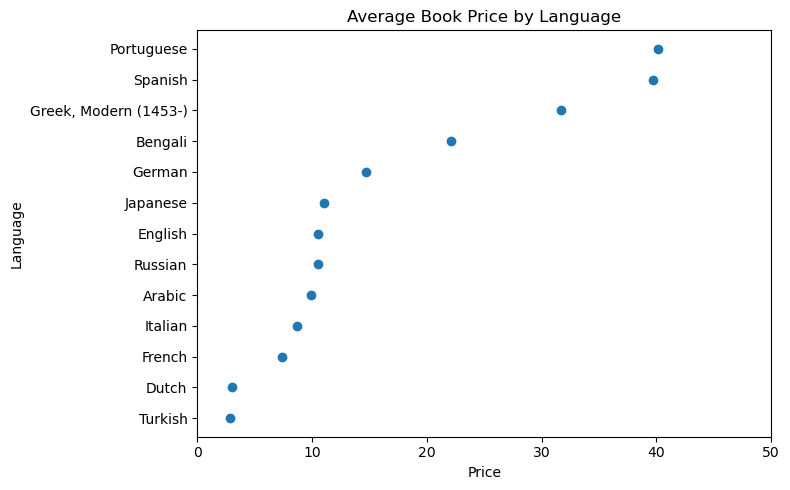

In [221]:
df1 = book_data
df1["price"] = df1["price"].astype(float)
df1 = (book_data.groupby("language", as_index=False)["price"].mean())
df1 = df1.sort_values("price")
plt.figure(figsize=(8,5))
y = np.arange(len(df1))
plt.plot(df1["price"].values, y, 'o')
plt.yticks(y, df1["language"].values)
plt.xlabel("Price")
plt.ylabel("Language")
plt.xlim(0, 50)
plt.title("Average Book Price by Language")
plt.tight_layout()
plt.show()

From the dot plot, one can see that the average price of books increases with each of the 13 languages. The Portugese language has the highest priced books while the Turkish language has the lowest priced books.

## Slope Graph Displaying the Change in Average Price (1978-200) across Book Formats

Slope Graphs emphasize change with connecting lines, annotates increases and decreases in data, and avoids clutter. This graph uses quantitative variables on the y-axis and years on the x axis. The following Slope Graph compares the average of each book price for different book formats across the first publication years of 1978 to 2000. 

C:\Users\katyj\AppData\Local\Temp\ipykernel_3924\2420337971.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



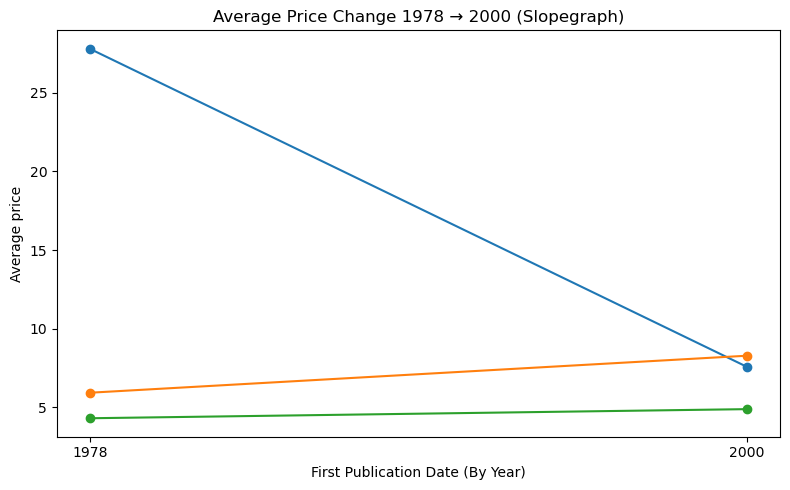

In [256]:
book_data["firstPublishDate"] = pd.to_datetime(book_data["firstPublishDate"])
book_data["year"] = book_data["firstPublishDate"].dt.year
df1 = book_data.sort_values("price", ascending=False)
p0, p1 = publish[10], publish[-71]

sub = df1[df1["year"].isin([p0, p1])]
sub["price"] = sub["price"].astype(float)

piv = sub.pivot_table(index="bookFormat", columns="year", values= "price", aggfunc = "mean")

# Slopegraph
plt.figure(figsize=(8,5))
for t in piv.index:
    plt.plot([0,1], [piv.loc[t, p0], piv.loc[t, p1]], marker='o')
plt.xticks([0,1], [p0, p1]); 
plt.ylabel("Average price")
plt.xlabel("First Publication Date (By Year)")
plt.title(f"Average Price Change {p0} → {p1} (Slopegraph)")
plt.tight_layout(); plt.show()

The book formats represented here are hardcover, mass market paperback, and paperback. Hardcover books are represented by the blue line, Mass Market Paperback books are represented by the orange line, and Paperback books are represented by the green line. Hardcover has the largest difference in average price from 1978 to 2000 and declines rapidly. Mass Market Paperback has the second largest average price difference from 1978 to 2000 with a slight incline. Paperback stays pretty consistent (very slight incline) between 1978 to 2000.

## Small-Multiples Chart Displaying Average Price Over Time by Language

Small-Multiples chart have the same axes and scales across panels to support rapid comparison, avoid changing y-limits between facets (unless explicitly noted), and order panels meaningfully (e.g., alphabetical, size, geography). The ordered panels here are by language (geographic region). The following small-multiples chart uses a shared y-scale to demonstrate how the average price of books changes over time of publishing for each language. 

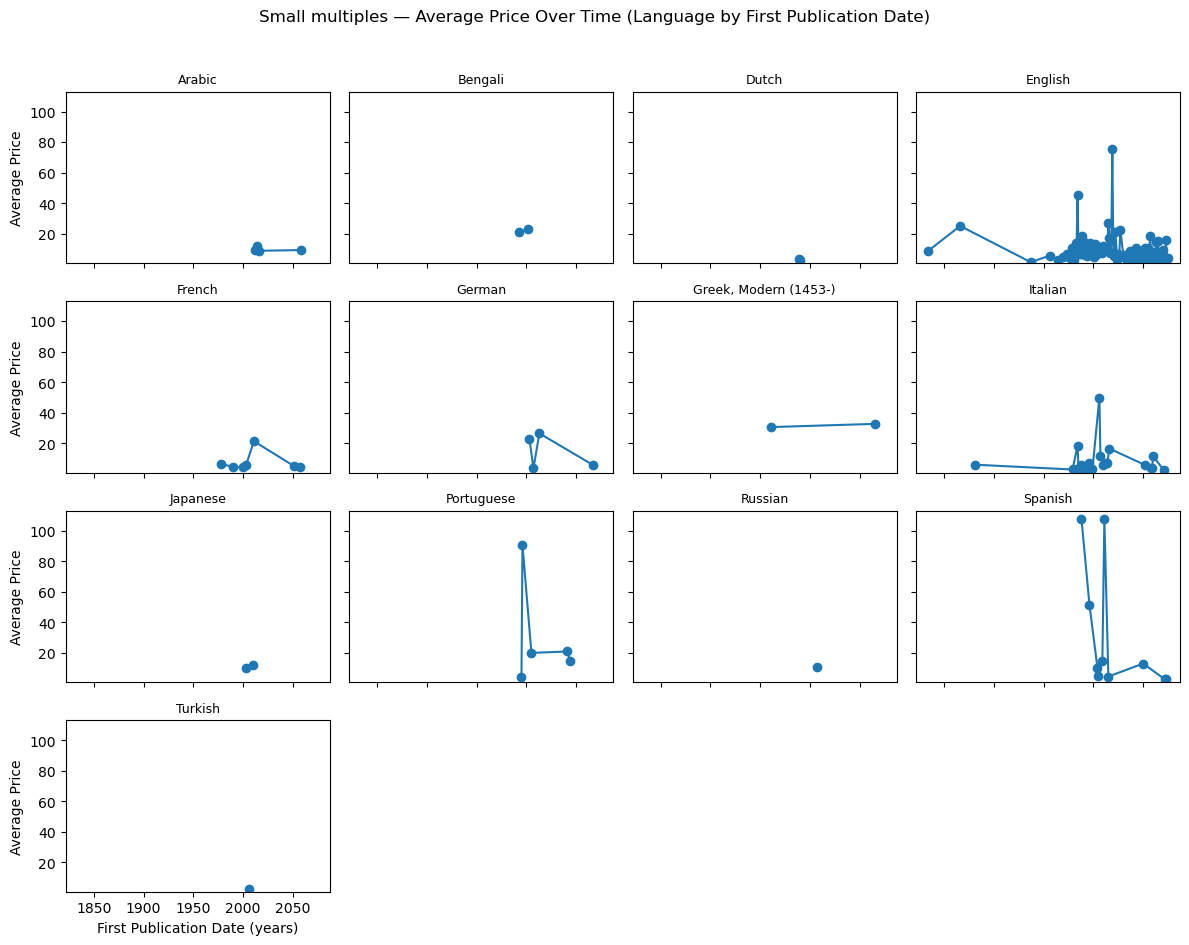

In [240]:
# Small multiples (shared axes)
book_data["firstPublishDate"] = pd.to_datetime(book_data["firstPublishDate"])
book_data["year"] = book_data["firstPublishDate"].dt.year
df1 = book_data.sort_values("price", ascending=False)
watch = df1["language"].tolist()
pivot = (df1[df1["language"].isin(watch)].pivot_table(index="year", columns="language", values="price", aggfunc = "mean"))
languages = list(pivot.columns)
n, cols = len(languages), 4
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(3.0*cols, 2.4*rows), sharex=True, sharey=True)
axes = axes.flatten()
ymin = pivot.min().min()*0.95
ymax = pivot.max().max()*1.05

for i, t in enumerate(languages):
    ax = axes[i]
    s = pivot[t].dropna()
    ax.plot(s.index, s.values, marker='o')
    ax.set_title(t, fontsize=9)
    ax.set_ylim(ymin, ymax)
    r, c = divmod(i, cols)
    if r == rows-1: 
        ax.set_xlabel("First Publication Date (years)")
    if c == 0:
        ax.set_ylabel("Average Price")
for j in range(i+1, rows*cols): 
    axes[j].set_visible(False)


fig.suptitle(f"Small multiples — Average Price Over Time (Language by First Publication Date)", y=0.98, fontsize=12)
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()


From the charts, one can see that the languages with the post points of average price change over time of publishing are English, French, German, Greek, Italian, Portugese, and Spanish. The ones that don't are Arabic, Bengali, Dutch, Japanese, Russian, and Turkish.

## Normalized View of Average Book Price across Languages

A normalized view can show percent change from a baseline. In this normalized view the average book price is represented per unit and represents a min-max normalization. The set baseline is on a 1.0 scale to compare trajectories. The normalized bar chart shows the normalization of average book price across languages.

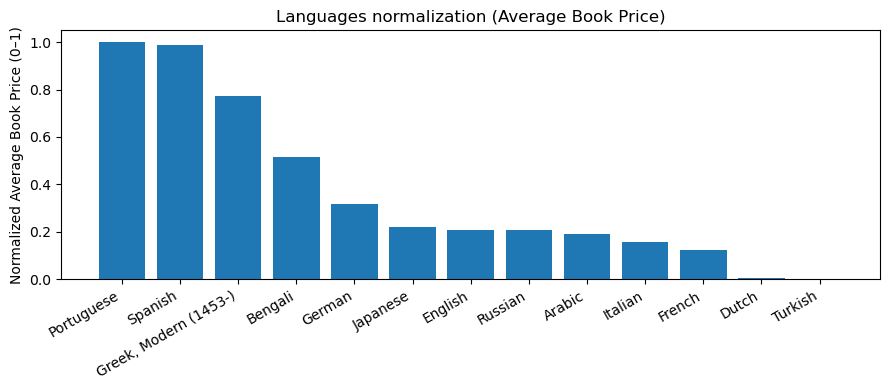

In [255]:
import matplotlib.pyplot as plt, numpy as np

df1 = book_data.groupby("language", as_index=False)["price"].mean()
df1 = df1.sort_values("price", ascending=False)

# Min-max normalization of average price
df1["normalized_price"] = (df1["price"] - df1["price"].min()) / (df1["price"].max() - df1["price"].min())

plt.figure(figsize=(9,4))
x = np.arange(len(df1))
plt.bar(x, df1["normalized_price"].values)
plt.xticks(x, df1["language"].values, rotation=30, ha="right")
plt.ylabel("Normalized Average Book Price (0–1)")
#plt.ylim(0, max(5+df1["price"].max(), df["price"].max()*1.1))
plt.title(f"Languages normalization (Average Book Price)")
plt.tight_layout()
plt.show()

The data is min-max normalized from 0 to 1, so we can assess which language has the highest and lowest average book prices relative to each other. The Bars near 1 will have the highest book price and the bars near 0 will have the lowest book price. The Portuguese language has the highest average book price while the Turkish language has the lowest.

## Reflection

The design that best supports my comparison question is the normalized view of average book prices across languages. This properly visualizes the comparison of the average price for each language by normalizing the maximum and minimum values, and displaying it on a 1.0 scale. The Dot plot makes the same comparisons, but can be more confusing to visualize and compare because the scale is not standardized, and the dots are more scattered. 

The slope graph is a good comparison when the time of publication is being compared to book formats and average price, but the time constraint was difficult to visualize with a sufficient amount of observations. I wanted to pick a time range that could show at least 3 of the many different book formats. With trial and error, the dates 1978-2000 showed the best comparisons for 3 types of book formats. The final visualization displayed the comparisons well and was easy to read, however the data is not very useful.

The small-multiples chart across a shared y-axis does not demonstrate the comparison question of average price change over time of publishing for each language. It does not provide easy-to-read visualizations that makes the comparisons less confusing for the viewer. However, one can see which average prices changed the most across languages.